[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/fw-ai/cookbook/blob/main/training/case-studies/embedding_support_search/airbnb_policy_embedding.ipynb)

# Embedding fine-tuning for support search

Your help center has thousands of articles and a user describes a messy real situation.
Which one actually *governs* it? This notebook contrastively fine-tunes
**Qwen3-Embedding-8B** on Airbnb Help Center scenarios and measures whether it helps.

## The result

72 optimizer steps over 769 pairs, scored on 228 held-out situations against all 877
articles:

| Metric | Base | Fine-tuned | Gain |
|---|---|---|---|
| MRR | 0.525 | **0.707** | **+35%** |
| nDCG@10 | 0.602 | 0.771 | +28% |
| Recall@10 | 0.868 | 0.974 | +12% |
| Recall@100 | 0.991 | 1.000 | +1% |

The correct article moves from rank ~1.9 to ~1.4 on average.

Fine-tuning pays here because the base model has **headroom**: Recall@100 of 0.991 against
an MRR of 0.525 means it pulls the right article into the top 100 almost every time, then
buries it around rank 2. That is a ranking problem inside a topically-similar set, which is
what in-batch contrastive training fixes. Section 6 breaks down which queries move.

## The data

[`profoz/airbnb-policy-scenarios`](https://huggingface.co/datasets/profoz/airbnb-policy-scenarios)
-- 997 scenarios (769 train / 228 test) over 877 articles, one governing article each.

```
situation : "A guest started smoking indoors, but the host never set a smoking policy..."
article   : "Safety tips for hosts of places to stay"
```

Relevance is not keyword overlap: the smoking question resolves to a *safety-tips* article,
not to whichever page says "smoking" most often.

## Prerequisites

```bash
pip install --pre "fireworks-ai[training]>=1.2.2" python-dotenv datasets \
            pytrec_eval-terrier matplotlib
```

`.env` at the repo root: `FIREWORKS_API_KEY`, `FIREWORKS_ACCOUNT_ID`, `HF_TOKEN`.

> Training and deployment provision real GPU and **cost money**. Run the cleanup cell.

In [1]:
# Environment, path setup, SDK client.
import json, os, re, sys, time, uuid
from pathlib import Path

import dotenv

dotenv.load_dotenv(dotenv.find_dotenv(usecwd=True), override=True)

_HERE = Path.cwd()
_CS_ROOT = _HERE
while _CS_ROOT != _CS_ROOT.parent and not (_CS_ROOT / "common" / "ep_eval.py").exists():
    _CS_ROOT = _CS_ROOT.parent
_REPO_ROOT = _CS_ROOT.parent.parent            # .../training/case-studies -> repo root
for _p in (str(_HERE), str(_CS_ROOT), str(_REPO_ROOT)):
    if _p not in sys.path:
        sys.path.insert(0, _p)

import retrieval_eval as R                      # local harness (see retrieval_eval.py)

assert os.getenv("FIREWORKS_API_KEY"), "FIREWORKS_API_KEY missing from .env"
ACCOUNT_ID = os.getenv("FIREWORKS_ACCOUNT_ID", "").replace("accounts/", "", 1)
assert ACCOUNT_ID, "FIREWORKS_ACCOUNT_ID missing from .env"
HF_TOKEN = os.getenv("HF_TOKEN")

from fireworks import Fireworks

client = Fireworks()

def wait_until(get_fn, ok, bad, label, every=20, tries=360):
    """Poll .state until it reaches an ok/bad state (the SDK has no wait_for)."""
    for i in range(tries):
        obj = get_fn()
        st = getattr(obj, "state", None)
        if i % 5 == 0 or st in ok or st in bad:
            print(f"[{label}] {i + 1:03d} state={st}")
        if st in ok:
            return obj
        if st in bad:
            raise RuntimeError(f"{label} failed: state={st}")
        time.sleep(every)
    raise TimeoutError(f"{label} did not finish after {tries} polls")

print("repo root:", _REPO_ROOT)

repo root: /Users/sinan/cookbook-casestudies


## Configuration

**`BATCH_SIZE = 32`.** With 769 pairs that is 24 steps per epoch, so 3 epochs lands at 72.

**`MAX_DOC_LEN = 3072`.** Article length is bimodal -- median 3.3k chars, but p95 is 45k
and the longest is 654k -- so text is capped at 12k chars (~3k tokens), which truncates
11% of documents. The same cap applies at eval, which is what makes the comparison honest.

In [2]:
# ---- models: three distinct resources, do not mix them up -----------------
# The trainer rejects the serving id with "not of kind base model, but EMBEDDING_MODEL",
# so training uses the tunable -ft-base plus a validated training shape.
TRAIN_BASE_MODEL = "accounts/pyroworks/models/qwen3-embedding-8b-ft-base"
TRAINING_SHAPE   = "accounts/fireworks/trainingShapes/qwen3-embedding-base-8b/versions/e3oirzs4"
DEPLOYMENT_SHAPE = "accounts/fireworks/deploymentShapes/qwen3-embedding-8b-minimal"
SERVE_BASE_MODEL = "accounts/fireworks/models/qwen3-embedding-8b"
TOKENIZER_MODEL  = "Qwen/Qwen3-Embedding-8B"

# ---- training ------------------------------------------------------------
BATCH_SIZE    = 32          # 769 pairs -> 24 steps/epoch
EPOCHS        = 3           # 72 optimizer steps
LEARNING_RATE = 1e-5
TEMPERATURE   = 0.02        # sharpens the softmax so positives clearly win
LORA_RANK     = 0           # 0 = full-parameter
OUTPUT_MODE   = "embedding" # client-side bidirectional InfoNCE
MAX_QUERY_LEN = 256         # situations are ~60 tokens; 256 is generous
MAX_DOC_LEN   = 3072

# ---- data ----------------------------------------------------------------
DATASET   = "profoz/airbnb-policy-scenarios"
DOC_CHARS = 12_000          # char cap before tokenization, applied at train AND eval

INSTRUCTION = ("Given a description of a host or guest situation, retrieve the Airbnb "
               "Help Center policy article that addresses it")

DATA_DIR  = Path("data");  DATA_DIR.mkdir(exist_ok=True)
CACHE_DIR = Path("cache"); CACHE_DIR.mkdir(exist_ok=True)

RUN_TAG            = f"airbnb-{uuid.uuid4().hex[:6]}"
TRAINED_MODEL_ID   = f"qwen3-emb-8b-{RUN_TAG}"       # Kind: HF_BASE_MODEL
EMBEDDING_MODEL_ID = f"qwen3-emb-8b-{RUN_TAG}-emb"   # Kind: EMBEDDING_MODEL
DEPLOYMENT_ID      = f"airbnbemb-{RUN_TAG}"
EXPORT_DIR         = Path("export") / TRAINED_MODEL_ID

# The recipe ships "Instruct: {}\nQuery:" with no trailing space; the Qwen3 convention
# uses "Query: ". retrieval_eval reads the template at call time, so patching the recipe
# module here keeps training and evaluation in lockstep.
import training.recipes.embedding_loop as _embedding_loop

_embedding_loop._QWEN3_INSTRUCTION_TEMPLATE = "Instruct: {}\nQuery: "
assert R.instruction_template() == "Instruct: {}\nQuery: "

print(f"batch {BATCH_SIZE} x {EPOCHS} epochs   seq caps: q<={MAX_QUERY_LEN} d<={MAX_DOC_LEN}")
print(f"query template: {R.format_query('<query>', '<instruction>')!r}")
print(f"run: {RUN_TAG}")

/Users/sinan/cookbook-casestudies/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


batch 32 x 3 epochs   seq caps: q<=256 d<=3072
query template: 'Instruct: <instruction>\nQuery: <query>'
run: airbnb-7773a8


## 1. Build the data

Four files: `pairs.jsonl` for training, plus `queries.jsonl` / `corpus.jsonl` /
`qrels.tsv` for eval. The corpus spans train *and* test articles, because retrieval has to
happen against the whole help center rather than the slice the eval questions came from.

In [3]:
from datasets import load_dataset

# Articles ship clean (no nav boilerplate, whitespace normalized), so the only
# preprocessing left is the length cap.
def clean(text: str) -> str:
    return text[:DOC_CHARS]

ds = load_dataset(DATASET, token=HF_TOKEN)
print({s: ds[s].num_rows for s in ds})

corpus, queries, qrels, pairs = {}, {}, {}, []

for split in ("train", "test"):
    for r in ds[split]:
        corpus[str(r["document_id"])] = clean(r["article"])

for r in ds["train"]:
    pairs.append({"query": r["situation"], "positive": corpus[str(r["document_id"])]})

# Key queries by row index, not document_id: several distinct situations legitimately
# resolve to the same article, and keying on the document would silently collapse them.
for i, r in enumerate(ds["test"]):
    qid = f"t{i}"
    queries[qid] = r["situation"]
    qrels[qid] = {str(r["document_id"]): 1}

R.write_jsonl(DATA_DIR / "pairs.jsonl", pairs)
R.write_jsonl(DATA_DIR / "queries.jsonl", [{"id": k, "text": v} for k, v in queries.items()])
R.write_jsonl(DATA_DIR / "corpus.jsonl", [{"id": k, "text": v} for k, v in corpus.items()])
R.write_qrels(DATA_DIR / "qrels.tsv", qrels)

steps = (len(pairs) // BATCH_SIZE) * EPOCHS
print(f"\n  corpus      : {len(corpus):,} articles")
print(f"  train pairs : {len(pairs):,}  -> {steps} optimizer steps")
print(f"  eval queries: {len(queries):,}  (1 relevant article each)")
lens = sorted(len(c) for c in corpus.values())
print(f"  article chars after cleaning: median {lens[len(lens) // 2]:,}  max {lens[-1]:,}")
print(f"\n  sample query   : {pairs[0]['query'][:180]}")
print(f"  sample positive: {pairs[0]['positive'][:180]}")

{'train': 769, 'test': 228}

  corpus      : 877 articles
  train pairs : 769  -> 72 optimizer steps
  eval queries: 228  (1 relevant article each)
  article chars after cleaning: median 3,125  max 12,000

  sample query   : A host wants to add their wifi speed to their Airbnb listing but is unsure how to do it and what the results mean for potential guests.
  sample positive: Testing your wifi speed - Airbnb Help Center Search HomeAll topicsManaging your listingListing detailsAmenities and guest resourcesTesting your wifi speedHow-to • Home hostTesting 


### Corpus hygiene: audit before you measure

A scraped corpus carries duplicates, binary blobs, and nav stubs, and each one corrupts
retrieval metrics in a different way. Duplicates are the dangerous kind: when two ids hold
byte-identical text, the model can retrieve the right *text* and still be scored wrong.

This cell audits whatever corpus you loaded and prices the duplicate problem directly, by
re-scoring with twins counted as correct. Run it on your own help center before trusting
any number.

In [4]:
import collections

CORPUS_RAW, QUERIES_RAW, QRELS_RAW = R.load_experiment(DATA_DIR)

def audit(corpus, queries, qrels):
    def is_binary(a):
        h = a[:400]
        return h.startswith("\x89PNG") or h.startswith("%PDF") or h.count("\ufffd") > 5

    by_text = collections.defaultdict(list)
    for d, t in corpus.items():
        by_text[t].append(d)
    twins = {d: v for v in by_text.values() if len(v) > 1 for d in v}
    binaries = [d for d, t in corpus.items() if is_binary(t)]
    stubs = [d for d, t in corpus.items() if len(t) < 900]
    affected = [q for q, g in qrels.items() if any(d in twins for d in g)]

    print(f"  documents            : {len(corpus):,}")
    print(f"  duplicate texts      : {len(twins):>4}  ({100 * len(twins) / len(corpus):.1f}% of corpus)")
    print(f"  binary blobs         : {len(binaries):>4}")
    print(f"  stubs (<900 chars)   : {len(stubs):>4}")
    print(f"  eval queries whose gold has a twin: {len(affected)}/{len(queries)}")
    return by_text, affected

by_text, affected = audit(CORPUS_RAW, QUERIES_RAW, QRELS_RAW)

# Price the duplicate problem: score once strictly, once with twins credited. The gap is
# how much of your metric is a scraping artifact rather than a model failure.
if affected:
    ec = R.EmbeddingClient(model=SERVE_BASE_MODEL, batch_size=8)
    dids, qids = list(CORPUS_RAW), list(QUERIES_RAW)
    dv = ec.embed([CORPUS_RAW[d] for d in dids], desc="audit docs")
    qv = ec.embed([R.format_query(QUERIES_RAW[q], INSTRUCTION) for q in qids], desc="audit queries")
    run = R.search(qv, dv, qids, dids, top_k=100)
    lenient = {q: {d: 1 for g in [qrels] for gold in g for d in by_text[CORPUS_RAW[gold]]}
               for q, qrels in QRELS_RAW.items()}
    strict_m, lenient_m = R.score(run, QRELS_RAW), R.score(run, lenient)
    print(f"\n  {'metric':<12} {'strict':>8} {'twins ok':>9} {'artifact':>9}")
    for k in ("nDCG@10", "MRR"):
        print(f"  {k:<12} {strict_m[k]:>8.3f} {lenient_m[k]:>9.3f} {lenient_m[k] - strict_m[k]:>+9.3f}")
    print("\n  -> that gap is the ceiling on how much deduping would buy you.")
else:
    print("\n  no duplicate golds -- metrics are not inflated by twin documents.")

  documents            : 877
  duplicate texts      :    2  (0.2% of corpus)
  binary blobs         :    0
  stubs (<900 chars)   :   15
  eval queries whose gold has a twin: 0/228

  no duplicate golds -- metrics are not inflated by twin documents.


## 2. Score the base model

Queries get an instruction prefix, documents never do -- that asymmetry is how
Qwen3-Embedding was trained, so eval must match or we measure a different input
distribution than we trained on. This is the number the fine-tune has to beat.

In [23]:
CORPUS, QUERIES, QRELS = R.load_experiment(DATA_DIR)
print(f"{len(CORPUS):,} docs | {len(QUERIES)} queries\n")

t0 = time.monotonic()
base_metrics = R.evaluate_model(
    SERVE_BASE_MODEL, CORPUS, QUERIES, QRELS,
    instruction=INSTRUCTION, label="base",
    batch_size=8, cache_dir=CACHE_DIR,
)
print(f"\nbase ({time.monotonic() - t0:.0f}s):")
for k, v in base_metrics.items():
    print(f"  {k:<12} {v:.4f}" if isinstance(v, float) else f"  {k:<12} {v}")

877 docs | 228 queries

  [base] loaded 877 cached doc vectors
  [base] queries: 29/29 batches (100.0%) eta     0s

base (2s):
  nDCG@10      0.6016
  nDCG@100     0.6304
  Recall@10    0.8684
  Recall@100   0.9912
  MRR          0.5247
  MAP@100      0.5247
  #queries     228


## 3. Fine-tune (GO LIVE)

Each batch builds a `B x B` cosine-similarity matrix and applies InfoNCE in both
directions -- the diagonal is the true pairs, every off-diagonal cell is a free negative.
Watch `in_batch_recall_at_1` climb, but treat it as a training signal rather than a
retrieval metric.

**Provisions real GPU and costs money.**

In [6]:
import logging
import training.recipes.embedding_loop as embedding_loop
from training.utils import TrainerConfig, WandBConfig

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s", force=True)

cfg = embedding_loop.Config(
    log_path=str(Path("embedding_logs") / RUN_TAG),
    base_model=TRAIN_BASE_MODEL,
    tokenizer_model=TOKENIZER_MODEL,
    dataset=str(DATA_DIR / "pairs.jsonl"),

    output_mode=OUTPUT_MODE,
    temperature=TEMPERATURE,
    batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    epochs=EPOCHS,

    max_query_len=MAX_QUERY_LEN,
    max_doc_len=MAX_DOC_LEN,
    query_instruction=INSTRUCTION,     # must match section 2 and section 5

    lora_rank=LORA_RANK,
    output_model_id=TRAINED_MODEL_ID,
    trainer=TrainerConfig(training_shape_id=TRAINING_SHAPE),
    wandb=WandBConfig(project="embedding-support-search", run_name=RUN_TAG),
)

t0 = time.monotonic()
result = embedding_loop.main(cfg)
TRAINED_MODEL = f"accounts/{ACCOUNT_ID}/models/{TRAINED_MODEL_ID}"
print(f"\ntrained {result['steps']} steps in {(time.monotonic() - t0) / 60:.1f} min")
print("promoted:", TRAINED_MODEL, "(Kind: HF_BASE_MODEL -- not servable as embeddings yet)")

2026-07-26 08:54:11,164 INFO Auto-resolved account ID: pyroworks
2026-07-26 08:54:11,164 INFO Creating RLOR job: POST https://api.fireworks.ai/v1/accounts/pyroworks/rlorTrainerJobs?trainingShape=accounts%2Ffireworks%2FtrainingShapes%2Fqwen3-embedding-base-8b%2Fversions%2Fe3oirzs4&rlorTrainerJobId=training-api-service-22efba28 (model=accounts/pyroworks/models/qwen3-embedding-8b-ft-base) (payload={'serviceMode': True, 'keepAlive': False, 'dataset': '', 'trainingConfig': {'baseModel': 'accounts/pyroworks/models/qwen3-embedding-8b-ft-base', 'loraRank': 0, 'learningRate': 1e-05}})
2026-07-26 08:54:11,724 INFO Created trainer job: training-api-service-22efba28
2026-07-26 08:54:11,902 INFO [0s] Trainer job training-api-service-22efba28: state=JOB_STATE_PENDING
2026-07-26 08:55:13,266 INFO [61s] Trainer job training-api-service-22efba28: state=JOB_STATE_CREATING
2026-07-26 08:56:14,531 INFO [122s] Trainer job training-api-service-22efba28: state=JOB_STATE_CREATING
2026-07-26 08:57:15,970 INFO 

{"type": "metrics", "step": 1, "loss:sum": 3.5255851571491803e-09, "total_tokens:sum": 27774.0, "loss": 0.2717701494693756, "loss_q2d": 0.21598882973194122, "loss_d2q": 0.3275514543056488, "in_batch_recall_at_1": 0.9375}


2026-07-26 08:57:50,645 INFO Step 2/72 | epoch 1 | loss=0.1380 q2d=0.1918 d2q=0.0842 recall@1=0.969 | 14.5s


{"type": "metrics", "step": 2, "loss:sum": 1.489294243484096e-07, "total_tokens:sum": 32427.0, "loss": 0.13799898326396942, "loss_q2d": 0.1917974352836609, "loss_d2q": 0.08420052379369736, "in_batch_recall_at_1": 0.96875}


2026-07-26 08:58:04,126 INFO Step 3/72 | epoch 1 | loss=0.0869 q2d=0.0544 d2q=0.1193 recall@1=1.000 | 13.5s


...

{"type": "metrics", "step": 71, "loss:sum": 1.0401320205133402e-07, "total_tokens:sum": 30465.0, "loss": 0.04212203249335289, "loss_q2d": 0.047768350690603256, "loss_d2q": 0.036475714296102524, "in_batch_recall_at_1": 1.0}


2026-07-26 09:12:49,475 INFO Step 72/72 | epoch 3 | loss=0.3049 q2d=0.4447 d2q=0.1651 recall@1=0.906 | 10.2s


{"type": "metrics", "step": 72, "loss:sum": -3.988214948291713e-07, "total_tokens:sum": 33468.0, "loss": 0.3048829734325409, "loss_q2d": 0.4446837604045868, "loss_d2q": 0.1650822013616562, "in_batch_recall_at_1": 0.90625}


2026-07-26 09:12:49,476 INFO Saving final checkpoint (step 72)...
2026-07-26 09:12:49,477 INFO Saving DCP checkpoint 'step-72'...
2026-07-26 09:13:19,310 INFO DCP checkpoint 'step-72' saved (29.8s)
2026-07-26 09:13:35,972 INFO Saving sampler checkpoint 'step-72'...
2026-07-26 09:14:05,502 INFO Sampler checkpoint 'step-72' saved (29.5s)
2026-07-26 09:14:06,021 INFO Sampler server-stored name 'step-72-c9c1af92' differs from caller name 'step-72'; using control-plane row for subsequent promotion.
2026-07-26 09:14:06,528 INFO Promoting newest promotable checkpoint: step-72-c9c1af92 -> qwen3-emb-8b-airbnb-7773a8
2026-07-26 09:14:06,529 INFO Promoting checkpoint 'step-72-c9c1af92' -> model 'accounts/pyroworks/models/qwen3-emb-8b-airbnb-7773a8'
2026-07-26 09:14:06,648 INFO Promotion operation started: accounts/pyroworks/operations/lklo3ugn
2026-07-26 09:14:06,648 INFO Operation accounts/pyroworks/operations/lklo3ugn: Checkpoint promotion queued
2026-07-26 09:14:16,756 INFO Operation accounts/


trained 72 steps in 20.4 min
promoted: accounts/pyroworks/models/qwen3-emb-8b-airbnb-7773a8 (Kind: HF_BASE_MODEL -- not servable as embeddings yet)


## 4. Re-register as an embedding model and deploy

The trainer promotes as `Kind: HF_BASE_MODEL`, a generative base -- deploy that and
`/v1/embeddings` answers on the generative path, skipping the `<|endoftext|>` append and
last-token pooling the model trained with, so the vectors are quietly wrong. Two things fix
it and **both** are required: re-register with `kind="EMBEDDING_MODEL"`, and deploy with an
embedding deployment shape. You cannot flip the kind in place -- `models.update(kind=...)`
silently no-ops on an existing model.

> Needs model-download access on your account. ~16 GB across 37 shards; downloads skip
> files already on disk, so an interrupted run resumes.

In [7]:
# 4a. Download the promoted checkpoint via signed URLs.
import requests
from concurrent.futures import ThreadPoolExecutor, as_completed

EXPORT_DIR.mkdir(parents=True, exist_ok=True)
urls = client.models.get_download_endpoint(model_id=TRAINED_MODEL_ID).filename_to_signed_urls
print(f"checkpoint: {len(urls)} files")

def _download(name, url):
    dest = EXPORT_DIR / Path(name).name          # flatten the storage prefix
    if dest.exists() and dest.stat().st_size > 0:
        return dest.stat().st_size, "cached"
    with requests.get(url, stream=True, timeout=1800) as r:
        r.raise_for_status()
        with open(dest, "wb") as f:
            for chunk in r.iter_content(8 << 20):
                f.write(chunk)
    return dest.stat().st_size, "downloaded"

t0, total = time.monotonic(), 0
with ThreadPoolExecutor(max_workers=16) as pool:
    futs = [pool.submit(_download, n, u) for n, u in urls.items()]
    for i, fut in enumerate(as_completed(futs), 1):
        size, _ = fut.result()
        total += size
        print(f"\r  {i}/{len(urls)} files  {total / 1e9:.1f} GB", end="", flush=True)
print(f"\n  {total / 1e9:.1f} GB in {(time.monotonic() - t0) / 60:.1f} min")

checkpoint: 47 files
  47/47 files  16.4 GB
  16.4 GB in 8.4 min


In [11]:
# 4b. Re-register the same weights as an EMBEDDING_MODEL.
files = sorted(p for p in EXPORT_DIR.iterdir() if p.is_file())
sizes = {p.name: p.stat().st_size for p in files}
print(f"uploading {len(files)} files, {sum(sizes.values()) / 1e9:.1f} GB")

# `base_model_details` is create-time only: models.update() ignores it, and a model
# registered without it cannot be deployed ("model is missing model_type"). Derive the
# fields from config.json.
_cfg = json.loads((EXPORT_DIR / "config.json").read_text())
_n_params = sum(f.stat().st_size for f in files if f.suffix == ".safetensors") // 2  # bf16
MODEL_SPEC = {
    "kind": "EMBEDDING_MODEL",
    "base_model_details": {
        "checkpoint_format": "HUGGINGFACE",
        "model_type": _cfg["model_type"],          # "qwen3"
        "moe": False,
        "parameter_count": str(_n_params),
        "supports_fireattention": True,
        "supports_mtp": False,
        "tunable": False,
        "world_size": 1,
    },
    "context_length": _cfg["max_position_embeddings"],   # 40960
}
print(f"registering as model_type={_cfg['model_type']} "
      f"ctx={_cfg['max_position_embeddings']:,} params~{_n_params / 1e9:.1f}B")

# Idempotent: re-running after a failed upload reuses the model rather than 409-ing.
# We still check the kind, so we never silently upload into a wrong-kind model.
try:
    client.models.create(model_id=EMBEDDING_MODEL_ID, model=MODEL_SPEC)
    print("created:", EMBEDDING_MODEL_ID)
except Exception as e:
    if "already exists" not in str(e):
        raise
    existing = client.models.get(model_id=EMBEDDING_MODEL_ID)
    assert existing.kind == "EMBEDDING_MODEL", (
        f"{EMBEDDING_MODEL_ID} exists with kind={existing.kind}; kind is immutable, "
        f"so delete it or bump RUN_TAG"
    )
    # base_model_details is also create-time only, so a model registered without it
    # can never be deployed -- catch that here rather than at deploy time.
    assert (existing.base_model_details and existing.base_model_details.api_model_type), (
        f"{EMBEDDING_MODEL_ID} was created without base_model_details, which cannot be "
        f"patched. Delete it (client.models.delete) or bump RUN_TAG and re-upload."
    )
    print("reusing existing:", EMBEDDING_MODEL_ID, f"(kind={existing.kind})")

EMBEDDING_MODEL = f"accounts/{ACCOUNT_ID}/models/{EMBEDDING_MODEL_ID}"

up = client.models.get_upload_endpoint(model_id=EMBEDDING_MODEL_ID, filename_to_size=sizes)

# The signed URLs cover three headers -- see X-Goog-SignedHeaders on the URL:
#   content-type;host;x-goog-content-length-range
# All three must be sent, and the length range must be the exact size as *both* bounds.
# "0,{size}" fails with SignatureDoesNotMatch; "{size},{size}" is what was signed.
def _upload(name, url, attempts=4):
    size = sizes[name]
    headers = {
        "Content-Type": "application/octet-stream",
        "x-goog-content-length-range": f"{size},{size}",
    }
    for a in range(attempts):
        try:
            with open(EXPORT_DIR / name, "rb") as f:   # streamed; requests sets Content-Length
                r = requests.put(url, data=f, headers=headers, timeout=1800)
            r.raise_for_status()
            return name
        except Exception:
            if a == attempts - 1:
                raise
            time.sleep(2 ** a)

t0 = time.monotonic()
with ThreadPoolExecutor(max_workers=16) as pool:
    futs = [pool.submit(_upload, n, u) for n, u in up.filename_to_signed_urls.items()]
    for i, fut in enumerate(as_completed(futs), 1):
        fut.result()
        print(f"\r  {i}/{len(futs)} files", end="", flush=True)
print(f"\n  uploaded in {(time.monotonic() - t0) / 60:.1f} min")

client.models.validate_upload(model_id=EMBEDDING_MODEL_ID)
m = wait_until(lambda: client.models.get(model_id=EMBEDDING_MODEL_ID),
               {"READY"}, {"FAILED"}, "embedding-model", every=15)
assert m.kind == "EMBEDDING_MODEL", f"expected EMBEDDING_MODEL, got {m.kind}"
print(f"{EMBEDDING_MODEL}  kind={m.kind}  state={m.state}")

uploading 47 files, 16.4 GB
registering as model_type=qwen3 ctx=40,960 params~8.2B
created: qwen3-emb-8b-airbnb-7773a8-emb
  47/47 files
  uploaded in 8.0 min
[embedding-model] 001 state=READY
accounts/pyroworks/models/qwen3-emb-8b-airbnb-7773a8-emb  kind=EMBEDDING_MODEL  state=READY


In [16]:
# 4c. Deploy on the embedding serving path. `deployment_shape` is load-bearing.
# Idempotent, like the model create above: re-running the cell reuses the deployment.
try:
    client.deployments.create(
        base_model=EMBEDDING_MODEL,
        deployment_id=DEPLOYMENT_ID,
        deployment_shape=DEPLOYMENT_SHAPE,
        min_replica_count=1,
    )
    print("creating deployment:", DEPLOYMENT_ID)
except Exception as e:
    if "already exists" not in str(e):
        raise
    print("reusing existing deployment:", DEPLOYMENT_ID)
dep = wait_until(lambda: client.deployments.get(DEPLOYMENT_ID),
                 {"READY"}, {"FAILED", "DELETING"}, "deploy")

# A dedicated deployment is not addressable by model name alone -- that returns
# error 1010 ("not available") even with the deployment READY. Requests must name the
# deployment with a `model#deployment` suffix, and it has to be the *fully qualified*
# deployment path; a bare deployment id also fails.
SERVE_MODEL = f"{EMBEDDING_MODEL}#accounts/{ACCOUNT_ID}/deployments/{DEPLOYMENT_ID}"
print("deployment ready:", dep.name)
print("serve as        :", SERVE_MODEL)

2026-07-26 10:29:31,308 INFO Retrying request to https://api.fireworks.ai/v1/accounts/pyroworks/deployments in 0.483308 seconds
2026-07-26 10:29:32,049 INFO Retrying request to https://api.fireworks.ai/v1/accounts/pyroworks/deployments in 0.811730 seconds


reusing existing deployment: airbnbemb-airbnb-7773a8
[deploy] 001 state=READY
deployment ready: accounts/pyroworks/deployments/airbnbemb-airbnb-7773a8
serve as        : accounts/pyroworks/models/qwen3-emb-8b-airbnb-7773a8-emb#accounts/pyroworks/deployments/airbnbemb-airbnb-7773a8


In [17]:
# Input-form invariance: embedding a raw string must equal embedding its token ids.
# This catches a model sitting on the generative serving path. If it fails, the
# deployment is missing its embedding shape and every metric below is meaningless.
import numpy as np
from transformers import AutoTokenizer

_tok = AutoTokenizer.from_pretrained(TOKENIZER_MODEL)
_probe = "A guest smoked indoors and the house rules never mentioned smoking."
_ids = _tok(_probe, add_special_tokens=True)["input_ids"]

_ec = R.EmbeddingClient(model=SERVE_MODEL)
_v_text = _ec.embed([_probe])[0]
_v_ids = np.asarray(_ec._post([_ids])[0], dtype=np.float32)
_v_ids /= max(np.linalg.norm(_v_ids), 1e-12)

_cos = float(_v_text @ _v_ids)
print(f"cosine(raw text, input_ids) = {_cos:.6f}   dim={len(_v_text)}")
assert _cos > 0.999, (
    f"NOT input-form invariant (cos={_cos:.4f}) -- the deployment is on the generative "
    f"path. Check it was created with --deployment-shape {DEPLOYMENT_SHAPE}."
)
print("input-form invariant: embeddings are on the correct serving path.")

cosine(raw text, input_ids) = 1.000000   dim=4096
input-form invariant: embeddings are on the correct serving path.


## 5. Before vs after

Same harness, same corpus, same instruction -- only the weights changed. With exactly one
relevant article per query, **MRR is the number to read**: it is the metric that moves when
ranking improves, while recall is near its ceiling either way.

In [18]:
t0 = time.monotonic()
tuned_metrics = R.evaluate_model(
    SERVE_MODEL, CORPUS, QUERIES, QRELS,
    instruction=INSTRUCTION, label="tuned",
    batch_size=8, cache_dir=CACHE_DIR,
)
print(f"\nfine-tuned ({time.monotonic() - t0:.0f}s)\n")
print(R.comparison_table(base_metrics, tuned_metrics))

b, t = base_metrics["MRR"], tuned_metrics["MRR"]
print(f"\nMRR {b:.3f} -> {t:.3f}  ({(t - b) / b:+.1%})")
print(f"average rank of the correct article: {1 / b:.2f} -> {1 / t:.2f}")

Path("results.json").write_text(json.dumps({
    "dataset": DATASET, "corpus": len(CORPUS), "queries": len(QUERIES),
    "steps": result["steps"], "batch_size": BATCH_SIZE, "epochs": EPOCHS,
    "instruction": INSTRUCTION,
    "base": base_metrics, "tuned": tuned_metrics,
}, indent=2))
print("\nsaved -> results.json")

  [tuned] docs: 110/110 batches (100.0%) eta     0s
  [tuned] queries: 29/29 batches (100.0%) eta     0s

fine-tuned (20s)

| Metric | Base | Fine-tuned | Relative gain |
|---|---|---|---|
| nDCG@10 | 0.602 | 0.771 | +28% |
| nDCG@100 | 0.630 | 0.778 | +23% |
| Recall@10 | 0.868 | 0.974 | +12% |
| Recall@100 | 0.991 | 1.000 | +1% |
| MRR | 0.525 | 0.707 | +35% |
| MAP@100 | 0.525 | 0.707 | +35% |

MRR 0.525 -> 0.707  (+34.8%)
average rank of the correct article: 1.91 -> 1.41

saved -> results.json


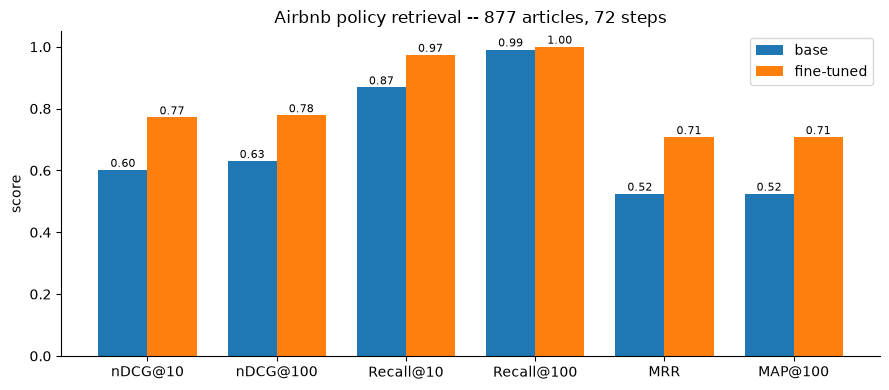

In [19]:
import matplotlib.pyplot as plt
import numpy as np

names = list(R.METRIC_KEYS.values())
b = [base_metrics[n] for n in names]
t = [tuned_metrics[n] for n in names]
x, w = np.arange(len(names)), 0.38

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w / 2, b, w, label="base")
ax.bar(x + w / 2, t, w, label="fine-tuned")
for i, (bv, tv) in enumerate(zip(b, t)):
    ax.text(i - w / 2, bv + .01, f"{bv:.2f}", ha="center", fontsize=8)
    ax.text(i + w / 2, tv + .01, f"{tv:.2f}", ha="center", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylim(0, 1.05); ax.set_ylabel("score")
ax.set_title(f"Airbnb policy retrieval -- {len(CORPUS):,} articles, {result['steps']} steps")
ax.legend(); ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.savefig("results.png", dpi=140); plt.show()

## 6. Inspect what changed

Aggregate metrics hide the interesting part. These are the queries the fine-tune moved
most, which is how you check it learned policy structure rather than surface wording.

In [21]:
def ranks(model, label):
    ec = R.EmbeddingClient(model=model, batch_size=8)
    qids = list(QUERIES)
    dids = list(CORPUS)
    qv = ec.embed([R.format_query(QUERIES[q], INSTRUCTION) for q in qids], desc=f"[{label}] q")
    dv = np.load(CACHE_DIR / f"docvecs_{model.replace('/', '_')}_{len(dids)}.npy")
    sims = qv @ dv.T
    order = np.argsort(-sims, axis=1)
    out = {}
    for i, q in enumerate(qids):
        gold = next(iter(QRELS[q]))
        out[q] = int(np.where(np.asarray(dids)[order[i]] == gold)[0][0]) + 1
    return out

rb, rt = ranks(SERVE_BASE_MODEL, "base"), ranks(SERVE_MODEL, "tuned")
delta = sorted(((rb[q] - rt[q], q) for q in rb), reverse=True)

print(f"\nimproved: {sum(1 for d, _ in delta if d > 0)}   "
      f"unchanged: {sum(1 for d, _ in delta if d == 0)}   "
      f"worse: {sum(1 for d, _ in delta if d < 0)}\n")

for tag, rows in (("BIGGEST GAINS", delta[:5]), ("BIGGEST REGRESSIONS", delta[-5:])):
    print(f"--- {tag} ---")
    for d, q in rows:
        print(f"  rank {rb[q]:>4} -> {rt[q]:<4} ({d:+d})   {QUERIES[q][:95]}")
    print()

  [base] q: 29/29 batches (100.0%) eta     0s
  [tuned] q: 29/29 batches (100.0%) eta     0s

improved: 115   unchanged: 88   worse: 25

--- BIGGEST GAINS ---
  rank  139 -> 2    (+137)   A new Airbnb host in Santiago wants to list their apartment but is unsure if their building all
  rank  129 -> 21   (+108)   A new Airbnb guest wants to know where to find information about cancellation options for their
  rank   80 -> 1    (+79)   A new Airbnb host is unsure where to find resources about hosting responsibly and wants to lear
  rank   64 -> 4    (+60)   A host decides to permanently delete their Airbnb account because they no longer wish to offer 
  rank   64 -> 6    (+58)   A guest wants to learn more about the protection options available to them during their stay an

--- BIGGEST REGRESSIONS ---
  rank    1 -> 5    (-4)   A host receives a message from a potential guest asking to book their property. The message con
  rank    4 -> 8    (-4)   A host realizes there is a sudden plumbi

## 7. Cleanup

The deployment bills while it exists. Delete it **before** the models, or model deletion
fails with `cannot delete model with active deployments`.

In [22]:
try:
    client.deployments.delete(DEPLOYMENT_ID, ignore_checks=True)
    print("deleted deployment:", DEPLOYMENT_ID)
except Exception:
    try:
        client.deployments.scale(DEPLOYMENT_ID, replica_count=0)
        print("scaled to 0 (delete blocked by recent traffic):", DEPLOYMENT_ID)
    except Exception as e:
        print("deployment cleanup:", str(e)[:150])

for mid in (EMBEDDING_MODEL_ID, TRAINED_MODEL_ID):
    try:
        client.models.delete(model_id=mid)
        print("deleted model:", mid)
    except Exception as e:
        print(f"skip {mid}: {str(e)[:120]}")

print("\nLocal artifacts left in place: data/, cache/, export/ (~16 GB). "
      "Remove export/ when you no longer need the checkpoint.")

deleted deployment: airbnbemb-airbnb-7773a8
skip qwen3-emb-8b-airbnb-7773a8-emb: Error code: 400 - {'code': 9, 'details': [], 'message': 'cannot delete model with active deployments'}
deleted model: qwen3-emb-8b-airbnb-7773a8

Local artifacts left in place: data/, cache/, export/ (~16 GB). Remove export/ when you no longer need the checkpoint.


## Bringing your own help center

All this needs from you is `pairs.jsonl` with `{"query", "positive"}` -- no negatives, the
other `B-1` articles in each batch supply those.

Run section 2 against your own corpus and read the gap between **Recall@100** and **MRR**.
High recall with mediocre MRR is the fine-tunable shape; high MRR means there is nothing to
win, and low Recall@100 means your problem is coverage, not ranking.